# MeatLens MobileNetV3Small Segmented 6-Fold CNN-Only Notebook

This notebook prepares the clean comparison experiment against the hybrid model:

- MobileNetV3Small only
- 6-fold cross-rotation only
- already-preprocessed HSV/LAB segmented `224x224` ROI images
- no handcrafted RGB/HSV/LAB/GLCM feature branch
- new output root only: `training_outputs/mobilenetv3small_segmented6_cnn_only/`


Transition-aware evaluation note:

Strict accuracy and macro F1 remain the primary evaluation metrics. Transition-aware metrics are added only as secondary analysis because pork freshness changes gradually and borderline images may visually fall between adjacent classes.


In [1]:
import importlib
import inspect

import pandas as pd
from IPython.display import Image as DisplayImage, display

import mobilenetv3small_segmented6_cnn_only_lib as segmented6_lib

segmented6_lib = importlib.reload(segmented6_lib)

print("Library source:", segmented6_lib.__file__)
print(
    "Function first lines:",
    {
        "train_segmented6_cnn_only_model": segmented6_lib.train_segmented6_cnn_only_model.__code__.co_firstlineno,
        "run_single_segmented6_cnn_only_experiment": segmented6_lib.run_single_segmented6_cnn_only_experiment.__code__.co_firstlineno,
    },
)
print(
    "Function source files:",
    {
        "train_segmented6_cnn_only_model": inspect.getsourcefile(segmented6_lib.train_segmented6_cnn_only_model),
        "run_single_segmented6_cnn_only_experiment": inspect.getsourcefile(segmented6_lib.run_single_segmented6_cnn_only_experiment),
    },
)

sanity_optimizer = segmented6_lib.make_optimizer(1e-3)
print("Sanity optimizer type:", type(sanity_optimizer))
print("Sanity optimizer module:", type(sanity_optimizer).__module__)

if inspect.getsourcefile(segmented6_lib.run_single_segmented6_cnn_only_experiment) != segmented6_lib.__file__:
    raise RuntimeError("Notebook is not using the module-backed experiment function.")

if "legacy" not in type(sanity_optimizer).__module__:
    raise RuntimeError("Notebook did not load the DirectML-safe legacy Adam optimizer.")

print("Notebook sanity check passed.")

segmented6_lib.ensure_output_dirs()
segmented6_lib.print_library_status()


[INFO] TensorFlow XLA/JIT disabled.
Library source: e:\Thesis Code\mobilenetv3small_segmented6_cnn_only_lib.py
Function first lines: {'train_segmented6_cnn_only_model': 510, 'run_single_segmented6_cnn_only_experiment': 597}
Function source files: {'train_segmented6_cnn_only_model': 'e:\\Thesis Code\\mobilenetv3small_segmented6_cnn_only_lib.py', 'run_single_segmented6_cnn_only_experiment': 'e:\\Thesis Code\\mobilenetv3small_segmented6_cnn_only_lib.py'}
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Sanity optimizer type: <class 'keras.optimizers.legacy.adam.Adam'>
Sanity optimizer module: keras.optimizers.legacy.adam
Notebook sanity check passed.
TF_AVAILABLE = True
SKLEARN_AVAILABLE = True
SKIMAGE_AVAILABLE = True
CV2_AVAILABLE = True
JOBLIB_AVAILABLE = True
SEABORN_AVAILABLE = True
PROJECT_ROOT = e:\Thesis Code
SEGMENTED_SPLITS_ROOT = e:\Thesis Code\generated_splits\cross_rotation_6fold_segmented
EXTENSION_OUTPUT_ROOT = e:\Thesis Code\training_outputs\mobilen

In [2]:
split_dfs = segmented6_lib.load_all_cross_rotation_splits()
print("Loaded split keys:", sorted(split_dfs.keys()))
resolved_counts = {
    split_key: int(df["image_path_resolved"].notna().sum())
    for split_key, df in split_dfs.items()
}
resolved_counts


Loaded split keys: ['fold1_test', 'fold1_train', 'fold1_val', 'fold2_test', 'fold2_train', 'fold2_val', 'fold3_test', 'fold3_train', 'fold3_val', 'fold4_test', 'fold4_train', 'fold4_val', 'fold5_test', 'fold5_train', 'fold5_val', 'fold6_test', 'fold6_train', 'fold6_val']


{'fold1_train': 2438,
 'fold1_val': 430,
 'fold1_test': 600,
 'fold2_train': 2438,
 'fold2_val': 430,
 'fold2_test': 600,
 'fold3_train': 2508,
 'fold3_val': 442,
 'fold3_test': 518,
 'fold4_train': 2480,
 'fold4_val': 438,
 'fold4_test': 550,
 'fold5_train': 2438,
 'fold5_val': 430,
 'fold5_test': 600,
 'fold6_train': 2438,
 'fold6_val': 430,
 'fold6_test': 600}

In [3]:
metadata_validation_df = segmented6_lib.validate_metadata_mapping(split_dfs)
metadata_validation_df


,sample_id,expected_sample_number,observed_rows,observed_sample_numbers,pork_cut,capture_source,phone_group,missing_image_path_rows
0,pork_shoulder_sample_1,1,3600,1,shoulder,researcher_home,old_phone,0
1,pork_shoulder_sample_2,2,3600,2,shoulder,partner_home,old_phone,0
2,pork_belly_sample_3,3,3108,3,belly,researcher_home,old_phone,0
3,pork_belly_sample_4,4,3300,4,belly,partner_home,old_phone,0
4,pork_ham_sample_5,5,3600,5,ham,researcher_home,new_phone,0
5,pork_ham_sample_6,6,3600,6,ham,partner_home,new_phone,0


In [4]:
quality_bundle = segmented6_lib.build_dataset_quality_summary(split_dfs)
segmented6_lib.print_quality_tables(quality_bundle)
quality_bundle["summary_df"].head(20)


Count per sample_id
             sample_id  count
   pork_belly_sample_3    518
   pork_belly_sample_4    550
     pork_ham_sample_5    600
     pork_ham_sample_6    600
pork_shoulder_sample_1    600
pork_shoulder_sample_2    600

Count per label
    label  count
    fresh   1068
not fresh   1200
  spoiled   1200

Count per sample_id x label
             sample_id     label  count
   pork_belly_sample_3     fresh    118
   pork_belly_sample_3 not fresh    200
   pork_belly_sample_3   spoiled    200
   pork_belly_sample_4     fresh    150
   pork_belly_sample_4 not fresh    200
   pork_belly_sample_4   spoiled    200
     pork_ham_sample_5     fresh    200
     pork_ham_sample_5 not fresh    200
     pork_ham_sample_5   spoiled    200
     pork_ham_sample_6     fresh    200
     pork_ham_sample_6 not fresh    200
     pork_ham_sample_6   spoiled    200
pork_shoulder_sample_1     fresh    200
pork_shoulder_sample_1 not fresh    200
pork_shoulder_sample_1   spoiled    200
pork_shoulder_sa

,section,sample_id,count,label,split_name,dataset_partition,fold,held_out_sample,test_contains_held_out_sample,held_out_absent_in_train,held_out_absent_in_val,train_val_overlap,train_test_overlap,val_test_overlap,metric_name,metric_value
0,count_per_sample_id,pork_belly_sample_3,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,count_per_sample_id,pork_belly_sample_4,550,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,count_per_sample_id,pork_ham_sample_5,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,count_per_sample_id,pork_ham_sample_6,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,count_per_sample_id,pork_shoulder_sample_1,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,count_per_sample_id,pork_shoulder_sample_2,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,count_per_label,NaN,1068,fresh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,count_per_label,NaN,1200,not fresh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,count_per_label,NaN,1200,spoiled,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,count_per_sample_id_label,pork_belly_sample_3,118,fresh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved sample image figure: e:\Thesis Code\training_outputs\mobilenetv3small_segmented6_cnn_only\figures\segmented_roi_sample_images.png


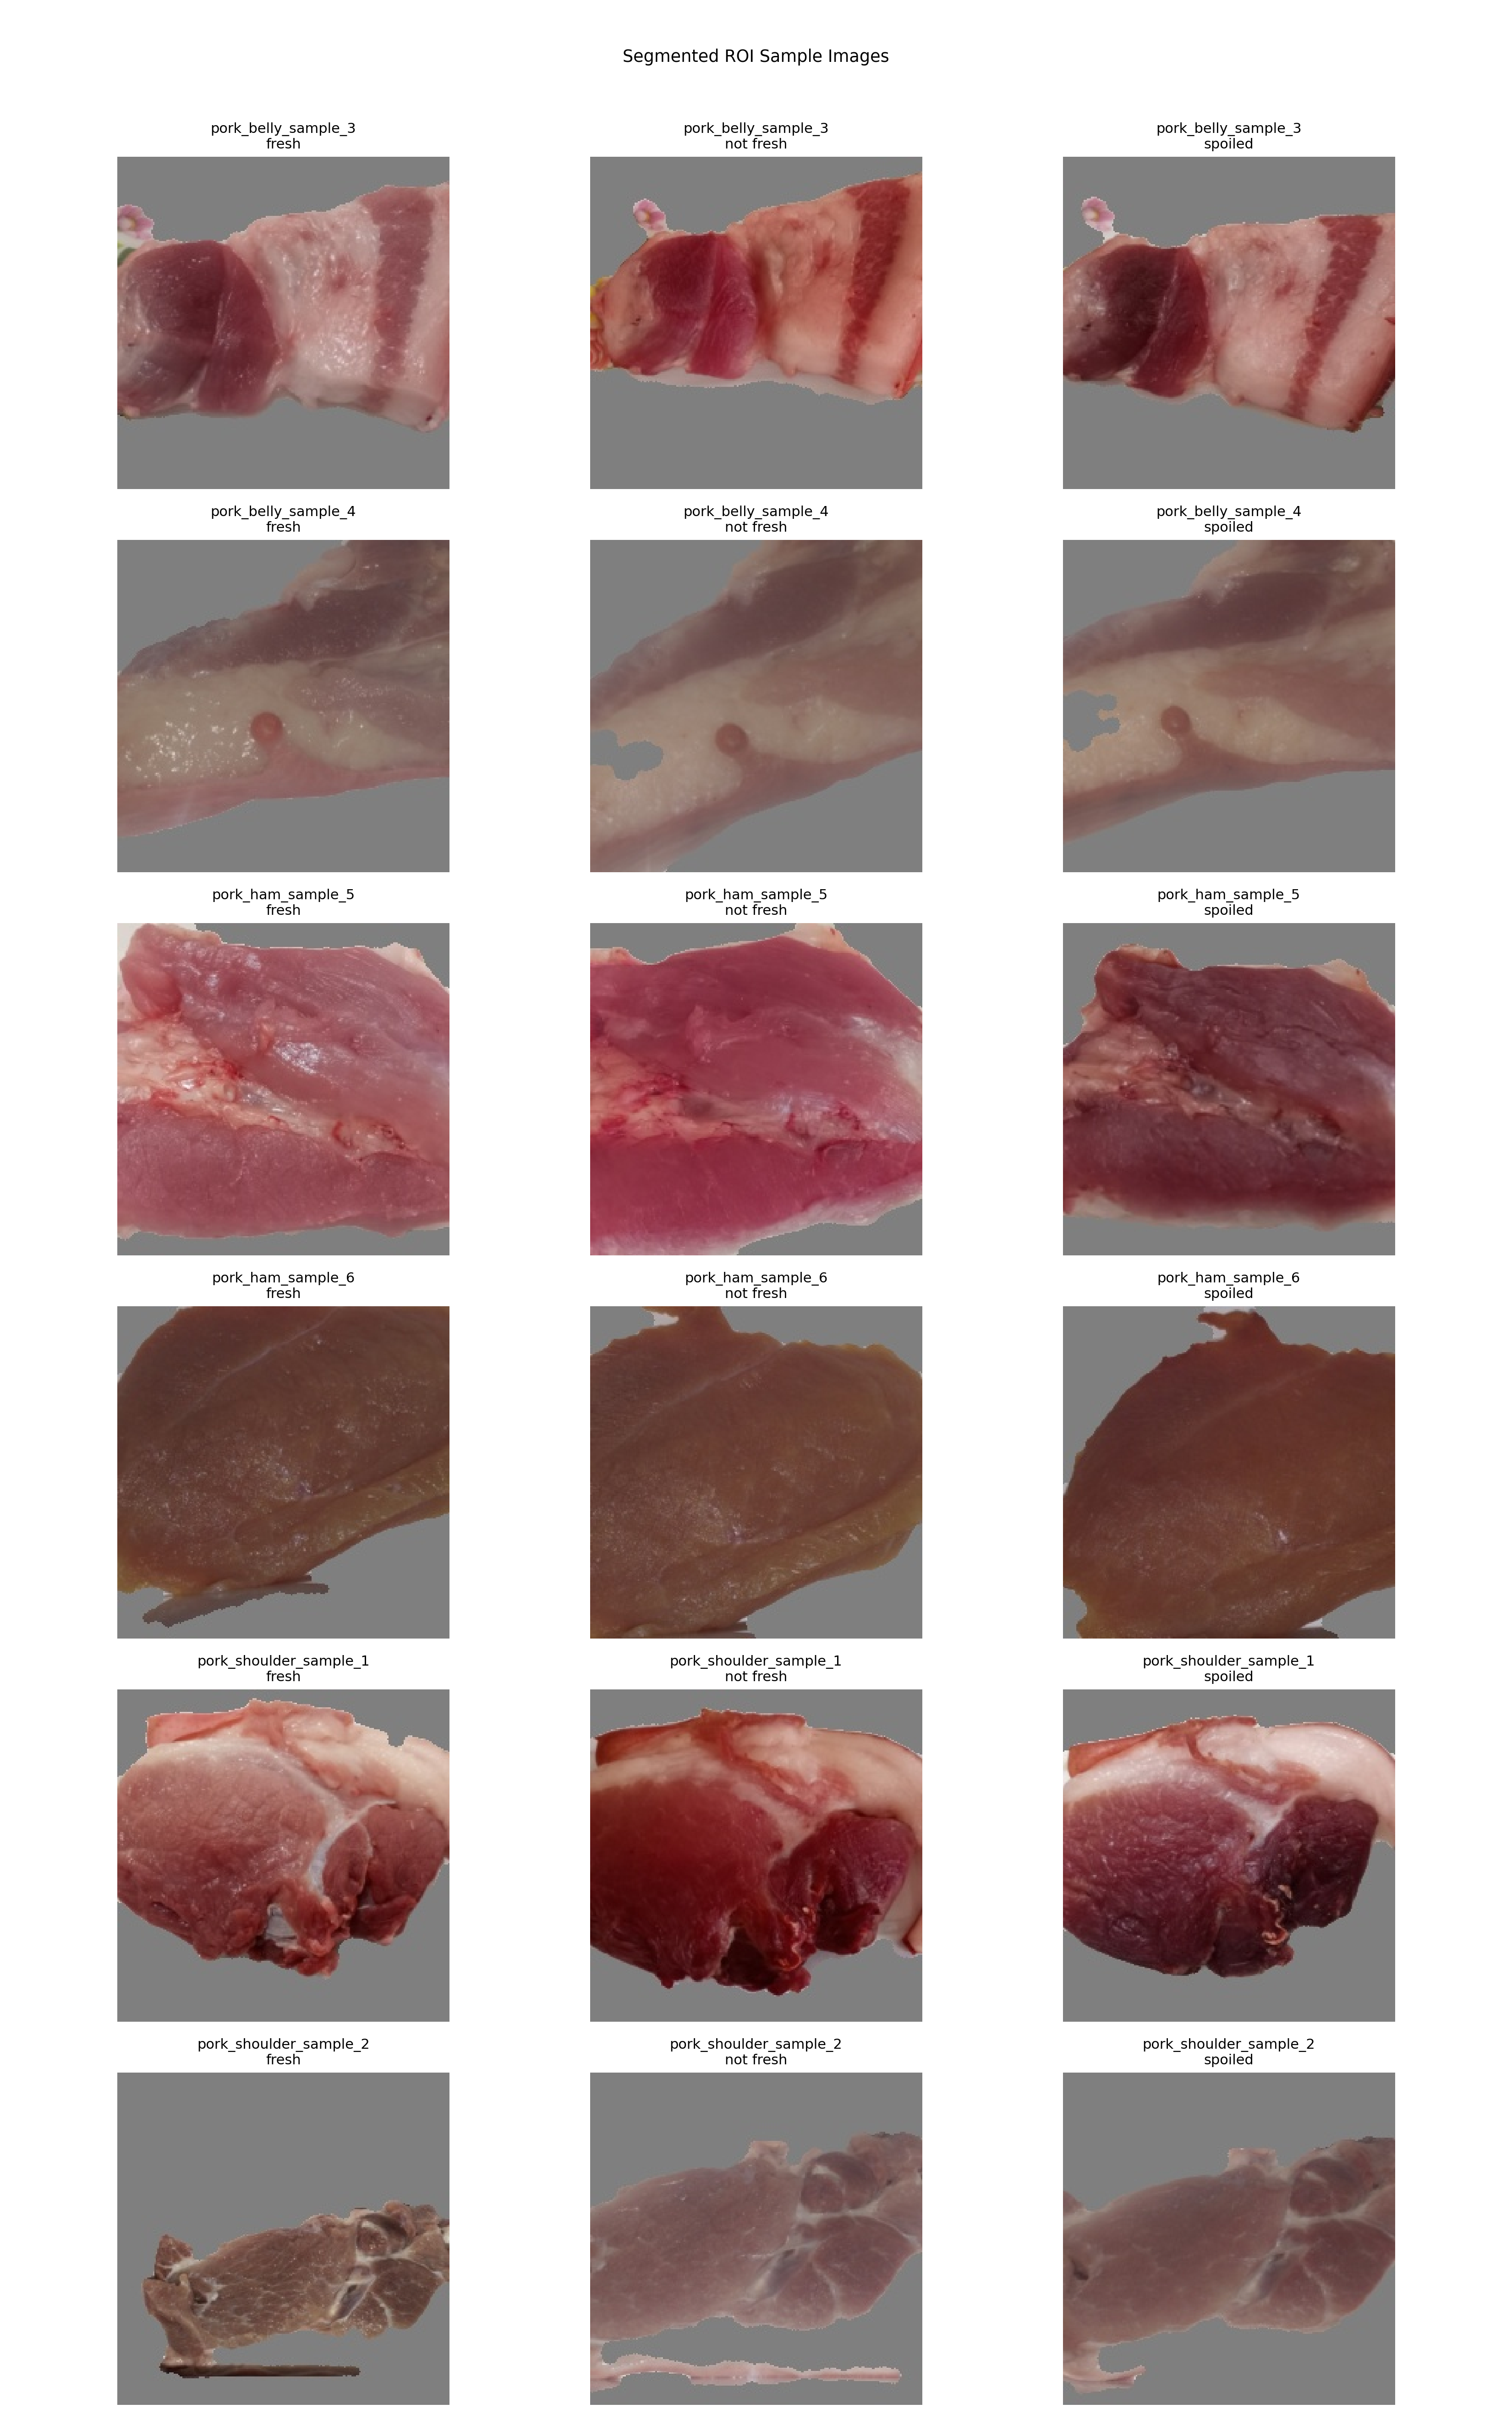

In [5]:
sample_image_figure_path = segmented6_lib.save_sample_visualization(split_dfs)
print("Saved sample image figure:", sample_image_figure_path)
display(DisplayImage(filename=str(sample_image_figure_path)))


In [6]:
print("Dataset quality summary CSV:", segmented6_lib.SEGMENTED6_QUALITY_SUMMARY_PATH)
print("Segmented 6-fold split root:", segmented6_lib.SEGMENTED_SPLITS_ROOT)
print("Output root:", segmented6_lib.EXTENSION_OUTPUT_ROOT)
print("Comparison CSV path:", segmented6_lib.SEGMENTED6_COMPARISON_PATH)


Dataset quality summary CSV: e:\Thesis Code\training_outputs\mobilenetv3small_segmented6_cnn_only\segmented6_dataset_quality_summary.csv
Segmented 6-fold split root: e:\Thesis Code\generated_splits\cross_rotation_6fold_segmented
Output root: e:\Thesis Code\training_outputs\mobilenetv3small_segmented6_cnn_only
Comparison CSV path: e:\Thesis Code\training_outputs\mobilenetv3small_segmented6_cnn_only\segmented6_hybrid_vs_cnn_only_comparison.csv


In [7]:
import inspect

source = inspect.getsource(segmented6_lib.train_segmented6_cnn_only_model)
print("Contains ModelCheckpoint?", "ModelCheckpoint" in source)
print("Contains load_weights?", "load_weights" in source)
print("Contains .weights.h5?", ".weights.h5" in source)
print("Contains feature_input?", "feature_input" in source)
print("Contains Concatenate?", "Concatenate" in source)


Contains ModelCheckpoint? False
Contains load_weights? False
Contains .weights.h5? False
Contains feature_input? False
Contains Concatenate? False


## Comparison Section

This section compares the completed hybrid metrics CSV against the CNN-only metrics CSV after CNN-only training has finished.


In [11]:
comparison_bundle = segmented6_lib.create_hybrid_vs_cnn_only_comparison()
if comparison_bundle is not None:
    comparison_bundle["comparison_df"]


## Manual Full Training Cell


In [9]:
MANUAL_CONFIRM_RUN_CNN_ONLY_TRAINING = True

if MANUAL_CONFIRM_RUN_CNN_ONLY_TRAINING:
    RUN_EXTENSION_TRAINING = True
    segmented6_lib.RUN_EXTENSION_TRAINING = RUN_EXTENSION_TRAINING
    all_results = segmented6_lib.run_segmented6_cnn_only_training()
else:
    print("CNN-only segmented6 training is ready but not started.")
    print("Set MANUAL_CONFIRM_RUN_CNN_ONLY_TRAINING = True to train.")


Running segmented CNN-only experiment: fold1 seed=42
[DATA] fold1 seed=42
  train_images count=2438 loaded_per_batch=32
  val_images count=430 loaded_per_batch=32
  test_images count=600 loaded_per_batch=32
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
[INFO] Compiled optimizer: keras.optimizers.legacy.adam.Adam
Epoch 1/8
 - val_f1_macro: 0.9057
77/77 - 10s - loss: 0.8963 - accuracy: 0.6099 - val_loss: 0.3871 - val_accuracy: 0.9023 - val_f1_macro: 0.9057 - lr: 5.0000e-04 - 10s/epoch - 133ms/step
Epoch 2/8
 - val_f1_macro: 0.9146
77/77 - 5s - loss: 0.4501 - accuracy: 0.8265 - val_loss: 0.2616 - val_accuracy: 0.9116 - val_f1_macro: 0.9146 - lr: 5.0000e-04 - 5s/epoch - 63ms/step
Epoch 3/8
 - val_f1_macro: 0.9460
77/77 - 5s - loss: 0.3090 - accuracy: 0.8897 - val_loss: 0.2005 - val_accuracy: 0.9442 - val_f1_macro: 0.9460 - lr: 5.0000e-04 - 5s/epoch - 65ms/step
Epoch 4/8
 - val_f1_macro: 0.9458
77/77 - 5s - loss: 0.2584 - accuracy: 0.9024 - val_loss: 0.1687 - val_

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpnknj4o3z\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpnknj4o3z\assets


Running segmented CNN-only experiment: fold1 seed=123
[DATA] fold1 seed=123
  train_images count=2438 loaded_per_batch=32
  val_images count=430 loaded_per_batch=32
  test_images count=600 loaded_per_batch=32
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
[INFO] Compiled optimizer: keras.optimizers.legacy.adam.Adam
Epoch 1/8
 - val_f1_macro: 0.9082
77/77 - 10s - loss: 0.8112 - accuracy: 0.6317 - val_loss: 0.3811 - val_accuracy: 0.9047 - val_f1_macro: 0.9082 - lr: 5.0000e-04 - 10s/epoch - 129ms/step
Epoch 2/8
 - val_f1_macro: 0.9115
77/77 - 5s - loss: 0.4132 - accuracy: 0.8523 - val_loss: 0.2736 - val_accuracy: 0.9093 - val_f1_macro: 0.9115 - lr: 5.0000e-04 - 5s/epoch - 65ms/step
Epoch 3/8
 - val_f1_macro: 0.9476
77/77 - 5s - loss: 0.3153 - accuracy: 0.8802 - val_loss: 0.1865 - val_accuracy: 0.9465 - val_f1_macro: 0.9476 - lr: 5.0000e-04 - 5s/epoch - 66ms/step
Epoch 4/8
 - val_f1_macro: 0.9524
77/77 - 5s - loss: 0.2557 - accuracy: 0.9081 - val_loss: 0.1710 - va

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpswvj1ek0\assets


...

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp4tva_unf\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp4tva_unf\assets


Running segmented CNN-only experiment: fold6 seed=2026
[DATA] fold6 seed=2026
  train_images count=2438 loaded_per_batch=32
  val_images count=430 loaded_per_batch=32
  test_images count=600 loaded_per_batch=32
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
[INFO] Compiled optimizer: keras.optimizers.legacy.adam.Adam
Epoch 1/8
 - val_f1_macro: 0.9319
77/77 - 13s - loss: 0.8623 - accuracy: 0.6210 - val_loss: 0.3387 - val_accuracy: 0.9302 - val_f1_macro: 0.9319 - lr: 5.0000e-04 - 13s/epoch - 174ms/step
Epoch 2/8
 - val_f1_macro: 0.9277
77/77 - 8s - loss: 0.3850 - accuracy: 0.8597 - val_loss: 0.2429 - val_accuracy: 0.9256 - val_f1_macro: 0.9277 - lr: 5.0000e-04 - 8s/epoch - 104ms/step
Epoch 3/8
 - val_f1_macro: 0.9437
77/77 - 8s - loss: 0.2688 - accuracy: 0.9069 - val_loss: 0.1957 - val_accuracy: 0.9419 - val_f1_macro: 0.9437 - lr: 5.0000e-04 - 8s/epoch - 103ms/step
Epoch 4/8
 - val_f1_macro: 0.9458
77/77 - 8s - loss: 0.2277 - accuracy: 0.9159 - val_loss: 0.1633 

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp25uvckwr\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp25uvckwr\assets


In [10]:
# debug_result = segmented6_lib.run_single_segmented6_cnn_only_experiment(
#     fold_name="fold1",
#     seed=42,
# )


In [12]:
import pandas as pd

seed_metrics_df = pd.read_csv(segmented6_lib.SEGMENTED6_SEED_METRICS_PATH)
display(seed_metrics_df)

print("Completed runs:", len(seed_metrics_df))
best_row = seed_metrics_df.sort_values("macro_f1", ascending=False).iloc[0]
print("Best run by macro F1:")
display(best_row[[
    "fold_name", "seed", "accuracy", "macro_f1",
    "top_2_accuracy", "adjacent_accuracy", "severe_error_rate",
    "model_path", "tflite_path"
]])

,timestamp,backbone,split_mode,fold_name,seed,model_input_mode,image_crop_mode,run_stem,model_path,tflite_path,...,spoiled_f1,spoiled_support,top_2_accuracy,adjacent_accuracy,severe_error_rate,mean_absolute_ordinal_error,borderline_rate,low_confidence_rate,adjacent_pair_combined_confidence_mean,non_adjacent_top2_rate
0,2026-05-18T16:18:47.089001,MobileNetV3Small,cross_rotation,fold1,42,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold1_seed42,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.694444,200,0.776667,1.000000,0.000000,0.320000,0.588333,0.168333,0.883545,0.403333
1,2026-05-18T16:20:55.934196,MobileNetV3Small,cross_rotation,fold1,123,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold1_seed123,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.603318,200,0.885000,0.875000,0.125000,0.576667,0.590000,0.213333,0.911672,0.311667
2,2026-05-18T16:23:05.881428,MobileNetV3Small,cross_rotation,fold1,2026,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold1_seed2026,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.675815,200,0.885000,0.995000,0.005000,0.330000,0.621667,0.101667,0.888600,0.331667
3,2026-05-18T16:25:48.697708,MobileNetV3Small,cross_rotation,fold2,42,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold2_seed42,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.672269,200,0.631667,0.750000,0.250000,0.651667,0.665000,0.103333,0.954022,0.128333
4,2026-05-18T16:28:11.097259,MobileNetV3Small,cross_rotation,fold2,123,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold2_seed123,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.661323,200,0.640000,0.740000,0.260000,0.666667,0.706667,0.183333,0.935552,0.080000
5,2026-05-18T16:30:33.946958,MobileNetV3Small,cross_rotation,fold2,2026,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold2_seed2026,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.682540,200,0.645000,0.751667,0.248333,0.628333,0.638333,0.120000,0.958418,0.028333
6,2026-05-18T16:32:58.613196,MobileNetV3Small,cross_rotation,fold3,42,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold3_seed42,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.855140,200,0.915058,1.000000,0.000000,0.312741,0.743243,0.214286,0.947106,0.113900
7,2026-05-18T16:35:25.079982,MobileNetV3Small,cross_rotation,fold3,123,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold3_seed123,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.836689,200,0.866795,1.000000,0.000000,0.312741,0.702703,0.206564,0.955214,0.115830
8,2026-05-18T16:37:53.462402,MobileNetV3Small,cross_rotation,fold3,2026,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold3_seed2026,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.850962,200,0.889961,1.000000,0.000000,0.339768,0.698842,0.223938,0.941646,0.098456
9,2026-05-18T16:40:22.778557,MobileNetV3Small,cross_rotation,fold4,42,cnn_only,preprocessed_segmented_roi_224,segmented6_cnn_only_fold4_seed42,e:\Thesis Code\training_outputs\mobilenetv3sma...,e:\Thesis Code\training_outputs\mobilenetv3sma...,...,0.617647,200,0.938182,0.950909,0.049091,0.476364,0.430909,0.096364,0.958338,0.020000


Completed runs: 18
Best run by macro F1:


fold_name                                                        fold4
seed                                                               123
accuracy                                                      0.676364
macro_f1                                                      0.670533
top_2_accuracy                                                0.905455
adjacent_accuracy                                             0.954545
severe_error_rate                                             0.045455
model_path           e:\Thesis Code\training_outputs\mobilenetv3sma...
tflite_path          e:\Thesis Code\training_outputs\mobilenetv3sma...
Name: 10, dtype: object